# EUC Latitudinal Width

Both figures show **depth-mean** UVEL and WVEL (0–250 m). EUC boundaries differ by method:

- **Figure 1:** boundaries from Method 1 — find depth of max U in ±1° band, walk N/S from that core lat/depth until U < 0.1 m/s
- **Figure 2:** boundaries from Method 2 — depth-mean U, start at lat=0, walk N/S until U < 0.1 m/s

Each figure: Row 1 = TPOSE-noVel, Row 2 = TPOSE-Vel, Row 3 = EUC width(lon) for both runs.
Time average covers all 4 assimilation windows (Sep 2012 – Jun 2013).

In [1]:
import sys
sys.path.insert(0, '/home/edavenport/analysis/vel-assim-manuscript')
from open_tpose import tpose2012to2013
from xmitgcm import open_mdsdataset
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmocean.cm as cmo

plt.rcParams['font.size'] = 12

## Configuration — edit run directories and output path here

In [ ]:
# Output directory for saved figures
fig_dir = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/wvel_changes/'

# Shared grid
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

# TPOSE-Vel assimilation run directories (one per window)
vel_runs = {
    'sep2012': '/data/SO3/edavenport/tpose6/sep2012/run_iter14',
    'nov2012': '/data/SO3/edavenport/tpose6/nov2012/run_iter20/',
    'jan2013': '/data/SO3/edavenport/tpose6/jan2013/run_iter14/',
    'mar2013': '/data/SO3/edavenport/tpose6/mar2013/run_iter16/',
}

## Load data

In [3]:
prefix = ['diag_state']
ds_novel = tpose2012to2013(prefix)

for coord in ['XC', 'YC', 'Z', 'XG', 'YG', 'Zl']:
    if coord in ds_novel.coords:
        ds_novel[coord] = ds_novel[coord].astype(float)

ds_novel = ds_novel.sel(time=slice('2012-09-01', '2013-06-30'))
print(f'noVel: {len(ds_novel.time)} days, {str(ds_novel.time.values[0])[:10]} to {str(ds_novel.time.values[-1])[:10]}')

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731
noVel: 303 days, 2012-09-01 to 2013-06-30


In [4]:
offset = 10
delta_t = 1200  # 1200 s/step (20 min), itPerFile=72 steps/day
itPerFile = 72

# sep2012: run_iter24  (first window — load from step 1, not offset)
num_diags = 30 + 31 + offset
intervals = range(itPerFile, itPerFile * num_diags, itPerFile)
ds_vel = open_mdsdataset(data_dir=vel_runs['sep2012'], grid_dir=grid_dir, iters=intervals,
                         prefix=prefix, ref_date='2012-08-31 12:00:00', delta_t=delta_t)

# nov2012: run_iter16
num_diags = 30 + 31 + offset
intervals = range(itPerFile * offset, itPerFile * num_diags, itPerFile)
ds_new = open_mdsdataset(data_dir=vel_runs['nov2012'], grid_dir=grid_dir, iters=intervals,
                         prefix=prefix, ref_date='2012-10-31 12:00:00', delta_t=delta_t)
ds_vel = xr.concat([ds_vel, ds_new], dim='time')

# jan2013: run_iter14
num_diags = 31 + 28 + offset
intervals = range(itPerFile * offset, itPerFile * num_diags, itPerFile)
ds_new = open_mdsdataset(data_dir=vel_runs['jan2013'], grid_dir=grid_dir, iters=intervals,
                         prefix=prefix, ref_date='2012-12-31 12:00:00', delta_t=delta_t)
ds_vel = xr.concat([ds_vel, ds_new], dim='time')

# mar2013: run_iter16
num_diags = 31 + 30 + 31 + 30 + 1  # mar–jun
intervals = range(itPerFile * offset, itPerFile * num_diags, itPerFile)
ds_new = open_mdsdataset(data_dir=vel_runs['mar2013'], grid_dir=grid_dir, iters=intervals,
                         prefix=prefix, ref_date='2013-03-01', delta_t=delta_t)
ds_vel = xr.concat([ds_vel, ds_new], dim='time')

for coord in ['XC', 'YC', 'Z', 'XG', 'YG', 'Zl']:
    if coord in ds_vel.coords:
        ds_vel[coord] = ds_vel[coord].astype(float)

print(f'Vel: {len(ds_vel.time)} days, {str(ds_vel.time.values[0])[:10]} to {str(ds_vel.time.values[-1])[:10]}')

Vel: 303 days, 2012-09-01 to 2013-07-01


## Sanity check: time-mean equatorial UVEL (depth vs longitude)

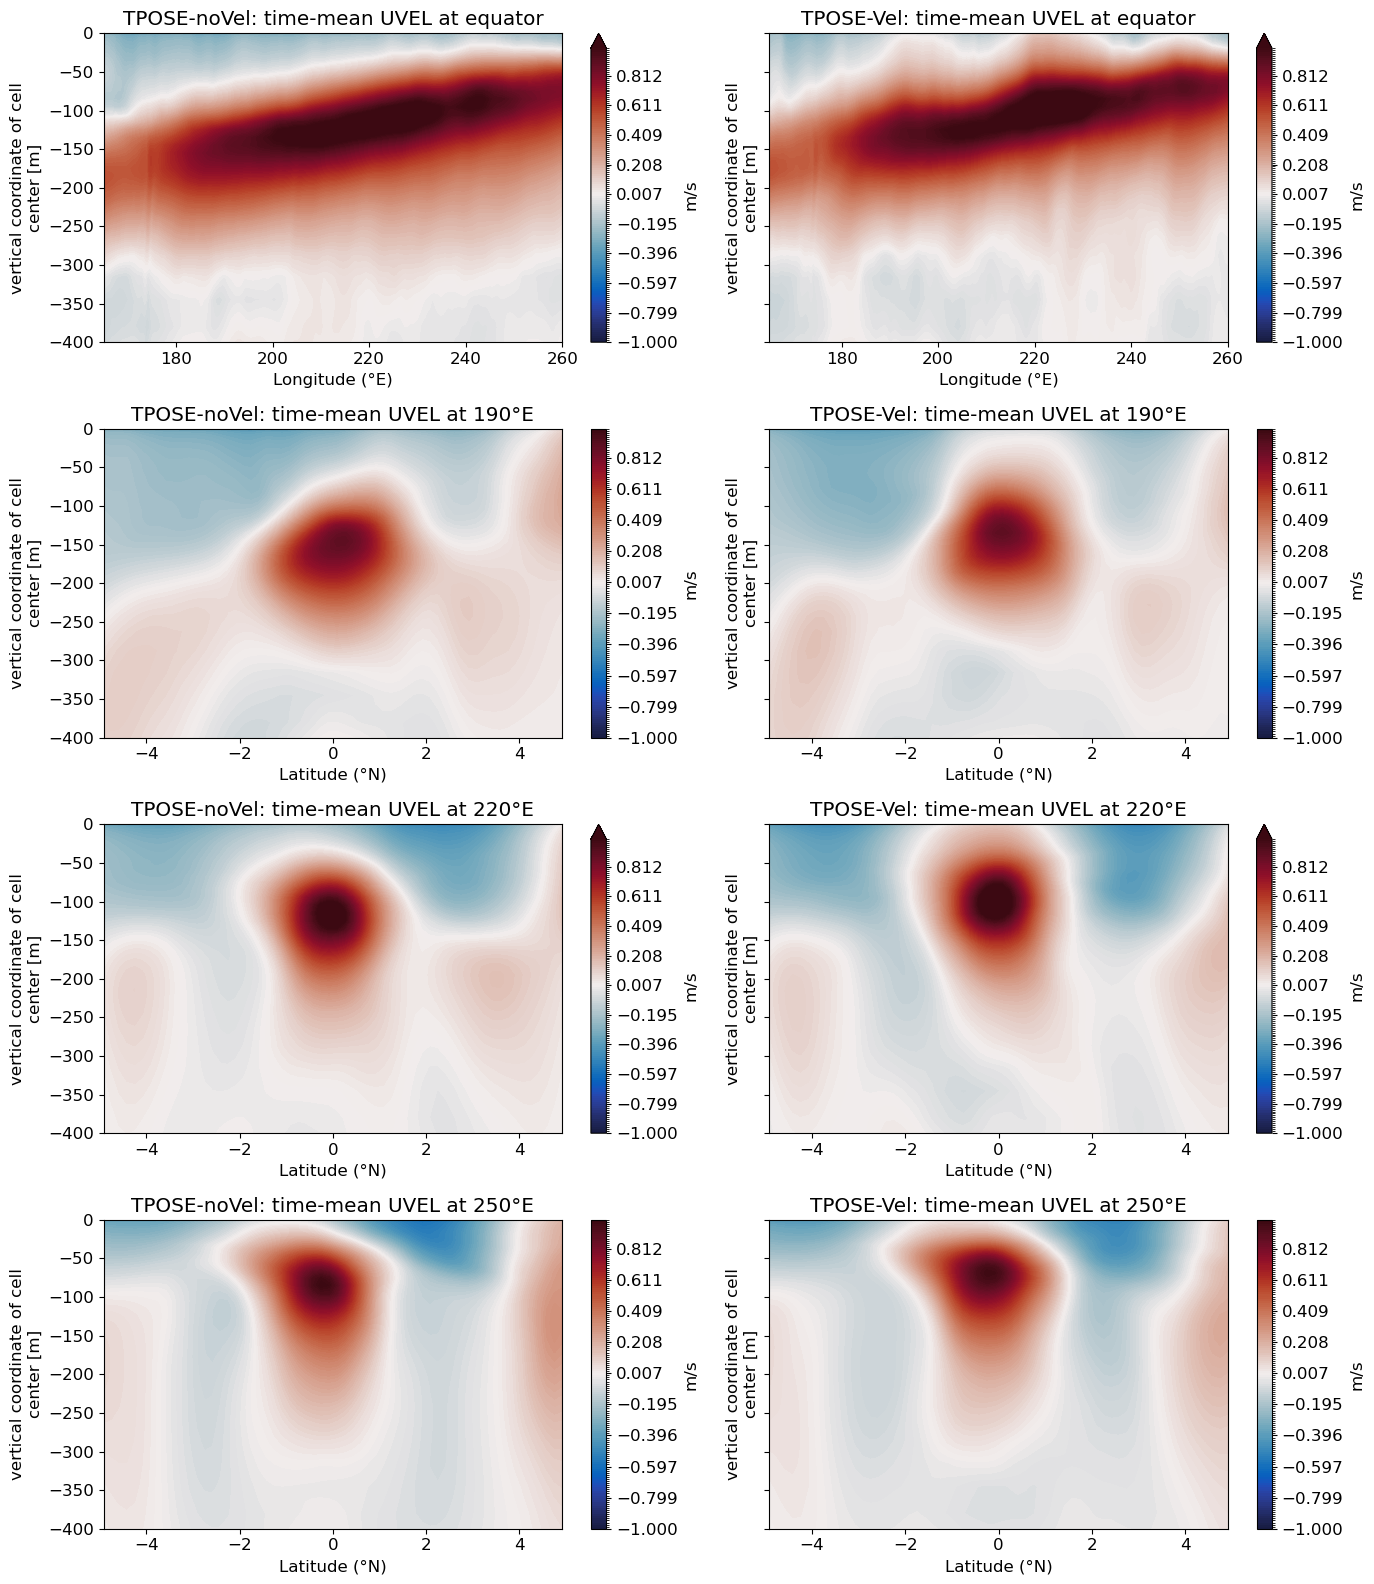

In [5]:
lon_slice = slice(165, 260)
levels = np.linspace(-1.0,1.0,150)
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey=True)

u_eq_novel = ds_novel.UVEL.sel(YC=0, method='nearest').sel(XG=lon_slice).mean(dim='time')
u_eq_novel.plot.contourf(ax=axes[0, 0], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[0, 0].set_title('TPOSE-noVel: time-mean UVEL at equator')
axes[0, 0].set_ylim(-400, 0)
axes[0, 0].set_xlabel('Longitude (°E)')

u_eq_lat_novel = ds_novel.UVEL.sel(XG=190, method='nearest').sel(YC=slice(-5, 5)).mean(dim='time')
u_eq_lat_novel.plot.contourf(ax=axes[1, 0], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[1, 0].set_title('TPOSE-noVel: time-mean UVEL at 190°E')
axes[1, 0].set_ylim(-400, 0)
axes[1, 0].set_xlabel('Latitude (°N)')

u_eq_lat_novel = ds_novel.UVEL.sel(XG=220, method='nearest').sel(YC=slice(-5, 5)).mean(dim='time')
u_eq_lat_novel.plot.contourf(ax=axes[2, 0], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[2, 0].set_title('TPOSE-noVel: time-mean UVEL at 220°E')
axes[2, 0].set_ylim(-400, 0)
axes[2, 0].set_xlabel('Latitude (°N)')

u_eq_lat_novel = ds_novel.UVEL.sel(XG=250, method='nearest').sel(YC=slice(-5, 5)).mean(dim='time')
u_eq_lat_novel.plot.contourf(ax=axes[3, 0], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[3, 0].set_title('TPOSE-noVel: time-mean UVEL at 250°E')
axes[3, 0].set_ylim(-400, 0)
axes[3, 0].set_xlabel('Latitude (°N)')

u_eq_vel = ds_vel.UVEL.sel(YC=0, method='nearest').sel(XG=lon_slice).mean(dim='time')
u_eq_vel.plot.contourf(ax=axes[0, 1], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[0, 1].set_title('TPOSE-Vel: time-mean UVEL at equator')
axes[0, 1].set_ylim(-400, 0)
axes[0, 1].set_xlabel('Longitude (°E)')

u_eq_lat_vel = ds_vel.UVEL.sel(XG=190, method='nearest').sel(YC=slice(-5, 5)).mean(dim='time')
u_eq_lat_vel.plot.contourf(ax=axes[1, 1], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[1, 1].set_title('TPOSE-Vel: time-mean UVEL at 190°E')
axes[1, 1].set_ylim(-400, 0)
axes[1, 1].set_xlabel('Latitude (°N)')

u_eq_lat_vel = ds_vel.UVEL.sel(XG=220, method='nearest').sel(YC=slice(-5, 5)).mean(dim='time')
u_eq_lat_vel.plot.contourf(ax=axes[2, 1], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[2, 1].set_title('TPOSE-Vel: time-mean UVEL at 220°E')
axes[2, 1].set_ylim(-400, 0)
axes[2, 1].set_xlabel('Latitude (°N)')

u_eq_lat_vel = ds_vel.UVEL.sel(XG=250, method='nearest').sel(YC=slice(-5, 5)).mean(dim='time')
u_eq_lat_vel.plot.contourf(ax=axes[3, 1], levels=levels, cmap=cmo.balance, cbar_kwargs={'label': 'm/s'})
axes[3, 1].set_title('TPOSE-Vel: time-mean UVEL at 250°E')
axes[3, 1].set_ylim(-400, 0)
axes[3, 1].set_xlabel('Latitude (°N)')

plt.tight_layout()
plt.show()
fig.savefig(fig_dir + 'UVEL_equatorial_sections.png', dpi=300, bbox_inches='tight')

## EUC boundary function

In [6]:
def calc_euc_width_depthmax(uvel_3d, threshold=0.25, lat_eq=(-1, 1)):
    """
    EUC boundaries using the depth-max (core-following) method on time-mean UVEL.

    For each longitude, finds the 2D maximum of UVEL over the (Z, lat) plane
    within ±lat_eq → gives (z_core, lat_core) simultaneously.
    Extracts U(lat) at z_core, then walks N/S from lat_core until U < threshold.

    Parameters
    ----------
    uvel_3d   : DataArray(Z, YC, XG) — time-mean UVEL, 0–250 m.
    threshold : float — EUC edge speed (m/s).
    lat_eq    : tuple — latitude band for locating the EUC core.
    """
    lats  = uvel_3d.YC.values
    lons  = uvel_3d.XG.values
    u_arr = uvel_3d.values        # (K, J, I)
    K, J, I = u_arr.shape

    lat_eq_mask = (lats >= lat_eq[0]) & (lats <= lat_eq[1])
    eq_inds     = np.where(lat_eq_mask)[0]
    n_eq        = len(eq_inds)

    # 2D argmax over (Z, lat_eq_band) at each longitude — gives z_core and lat_core
    u_eq      = u_arr[:, lat_eq_mask, :]          # (K, n_eq, I)
    u_eq_flat = u_eq.reshape(K * n_eq, I)
    flat_idx  = np.nanargmax(u_eq_flat, axis=0)   # (I,)
    i_z_core   = flat_idx // n_eq
    i_lat_core = eq_inds[flat_idx % n_eq]         # global lat index

    lat_north = np.full(I, np.nan)
    lat_south = np.full(I, np.nan)

    for j in range(I):
        i_z   = i_z_core[j]
        i_lat = i_lat_core[j]
        u_prof = u_arr[i_z, :, j]

        if u_prof[i_lat] < threshold:
            continue

        # Walk northward from core lat
        i_north = J - 1
        for i in range(i_lat + 1, J):
            if u_prof[i] < threshold:
                i_north = i - 1
                break

        # Walk southward from core lat
        i_south = 0
        for i in range(i_lat - 1, -1, -1):
            if u_prof[i] < threshold:
                i_south = i + 1
                break

        lat_north[j] = lats[i_north]
        lat_south[j] = lats[i_south]

    lat_north_da = xr.DataArray(lat_north, coords={'XG': lons}, dims='XG')
    lat_south_da = xr.DataArray(lat_south, coords={'XG': lons}, dims='XG')
    width_da     = lat_north_da - lat_south_da
    return lat_north_da, lat_south_da, width_da


def calc_euc_width_depthmean(uvel_2d, threshold=0.25):
    """
    EUC boundaries using the depth-mean method.

    For each longitude, starts at lat=0 and walks N/S through the time-mean,
    depth-mean U profile until U first drops below threshold.

    Parameters
    ----------
    uvel_2d   : DataArray(YC, XG) — time-mean, depth-mean UVEL over 0–250 m.
    threshold : float — EUC edge speed (m/s).
    """
    lats  = uvel_2d.YC.values
    lons  = uvel_2d.XG.values
    u_arr = uvel_2d.values        # (J, I)
    J, I  = u_arr.shape

    i_eq = int(np.argmin(np.abs(lats)))  # index closest to lat=0

    lat_north = np.full(I, np.nan)
    lat_south = np.full(I, np.nan)

    for j in range(I):
        u_prof = u_arr[:, j]

        if u_prof[i_eq] < threshold:
            continue

        i_north = J - 1
        for i in range(i_eq + 1, J):
            if u_prof[i] < threshold:
                i_north = i - 1
                break

        i_south = 0
        for i in range(i_eq - 1, -1, -1):
            if u_prof[i] < threshold:
                i_south = i + 1
                break

        lat_north[j] = lats[i_north]
        lat_south[j] = lats[i_south]

    lat_north_da = xr.DataArray(lat_north, coords={'XG': lons}, dims='XG')
    lat_south_da = xr.DataArray(lat_south, coords={'XG': lons}, dims='XG')
    width_da     = lat_north_da - lat_south_da
    return lat_north_da, lat_south_da, width_da


def add_boundaries(ax, n, s):
    ax.plot(n.XG.values, n.values, '-',  lw=1.5, color='k', label='N boundary')
    ax.plot(s.XG.values, s.values, '--', lw=1.5, color='k', label='S boundary')
    ax.legend(fontsize=9, loc='upper right')

## Compute depth-reduced fields and EUC boundaries

In [7]:
lon_slice = slice(165, 260)
lat_map   = slice(-10, 10)

# Full 3D time-mean UVEL (0-250m) — input for Method 1 (depth-max/core-following)
uvel_3d_novel = ds_novel.UVEL.sel(Z=slice(0, -250), YC=lat_map, XG=lon_slice).mean(dim='time')
uvel_3d_vel   = ds_vel.UVEL.sel(Z=slice(0, -250), YC=lat_map, XG=lon_slice).mean(dim='time')

# Depth-mean UVEL — map panels + Method 2 boundary input
umean_novel = uvel_3d_novel.mean(dim='Z')
umean_vel   = uvel_3d_vel.mean(dim='Z')

# Depth-mean WVEL — map panels
wmean_novel = (ds_novel.WVEL.sel(Zl=slice(0, -250)).mean(dim='Zl')
               .mean(dim='time').sel(XC=lon_slice, YC=lat_map))
wmean_vel   = (ds_vel.WVEL.sel(Zl=slice(0, -250)).mean(dim='Zl')
               .mean(dim='time').sel(XC=lon_slice, YC=lat_map))

print('depth-mean UVEL (noVel):', round(float(umean_novel.min()),4), 'to', round(float(umean_novel.max()),4), 'm/s')
print('depth-mean WVEL (noVel):', round(float(wmean_novel.min()),6), 'to', round(float(wmean_novel.max()),6), 'm/s')

depth-mean UVEL (noVel): -0.3213 to 0.43 m/s
depth-mean WVEL (noVel): -3.6e-05 to 5.8e-05 m/s


In [8]:
# Method 1: depth-max / core-following (3D UVEL input)
n_max_novel, s_max_novel, w_max_novel = calc_euc_width_depthmax(uvel_3d_novel)
n_max_vel,   s_max_vel,   w_max_vel   = calc_euc_width_depthmax(uvel_3d_vel)

# Method 2: depth-mean, start at equator (2D UVEL input)
n_mean_novel, s_mean_novel, w_mean_novel = calc_euc_width_depthmean(umean_novel)
n_mean_vel,   s_mean_vel,   w_mean_vel   = calc_euc_width_depthmean(umean_vel)

print(f'depth-max:  mean width noVel = {float(w_max_novel.mean()):.2f}°, Vel = {float(w_max_vel.mean()):.2f}°')
print(f'depth-mean: mean width noVel = {float(w_mean_novel.mean()):.2f}°, Vel = {float(w_mean_vel.mean()):.2f}°')

depth-max:  mean width noVel = 2.63°, Vel = 2.59°
depth-mean: mean width noVel = 1.07°, Vel = 1.21°


## Figure 1: depth-mean fields, EUC boundaries from depth-max core method

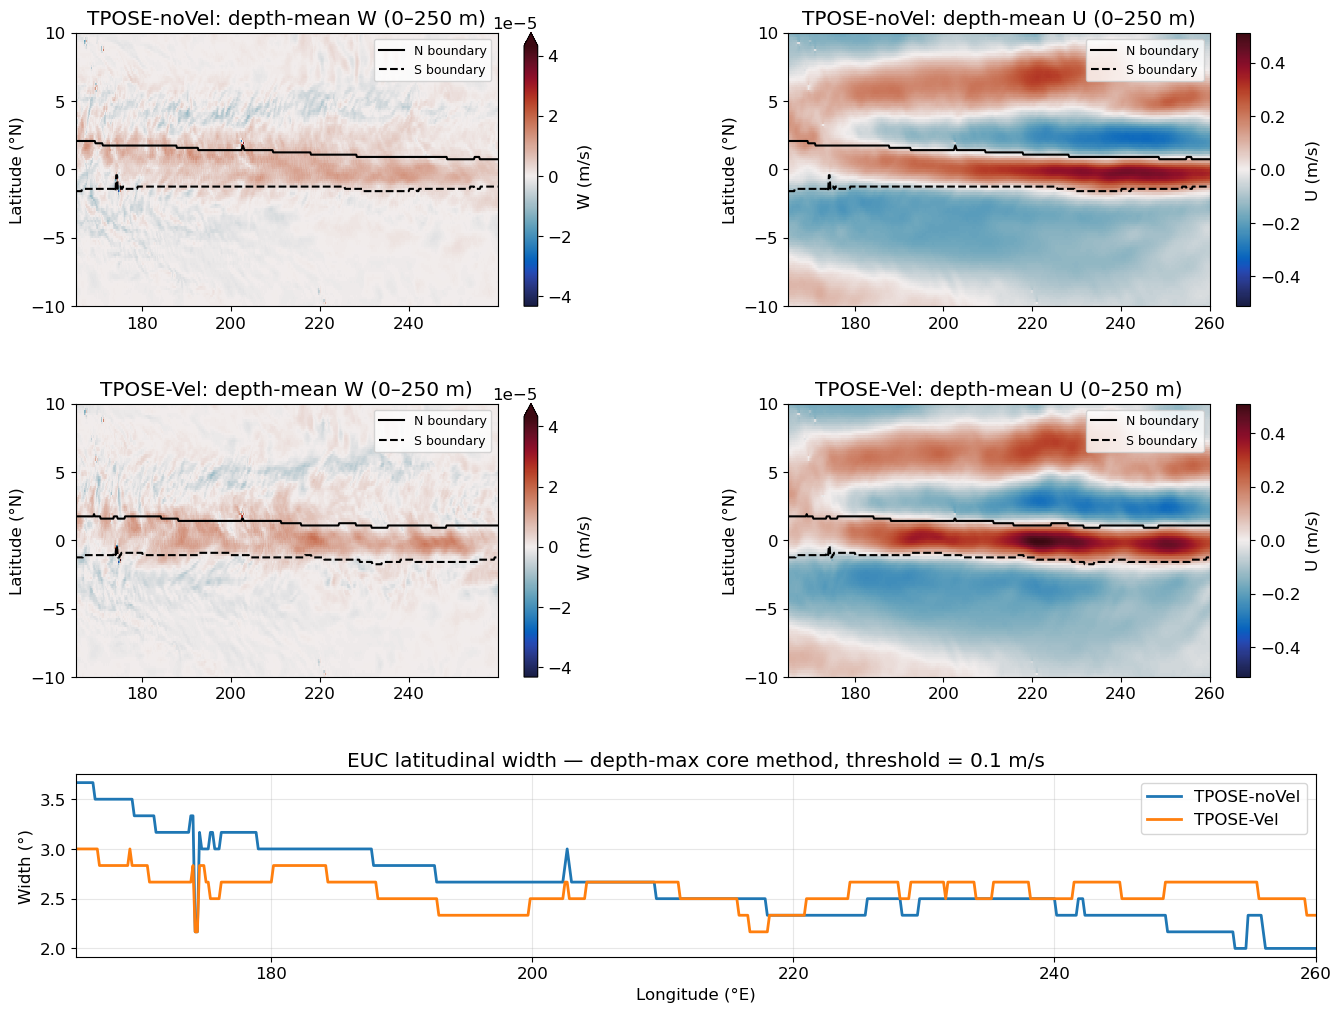

Saved EUC_width_depthmax.png


In [9]:
wlim2    = float(max(abs(wmean_novel).max(), abs(wmean_vel).max()))*0.75
ulim_abs = float(max(abs(umean_novel).max(), abs(umean_vel).max()))

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[3, 3, 2], hspace=0.4, wspace=0.35)

# Row 1: noVel — depth-mean fields, Method 1 (depth-max core) boundaries
ax00 = fig.add_subplot(gs[0, 0])
wmean_novel.plot(ax=ax00, vmin=-wlim2, vmax=wlim2, cmap=cmo.balance, cbar_kwargs={'label': 'W (m/s)'})
add_boundaries(ax00, n_max_novel, s_max_novel)
ax00.set_title('TPOSE-noVel: depth-mean W (0–250 m)')
ax00.set_xlabel('');  ax00.set_ylabel('Latitude (°N)')

ax01 = fig.add_subplot(gs[0, 1])
umean_novel.plot(ax=ax01, vmin=-ulim_abs, vmax=ulim_abs, cmap=cmo.balance, cbar_kwargs={'label': 'U (m/s)'})
add_boundaries(ax01, n_max_novel, s_max_novel)
ax01.set_title('TPOSE-noVel: depth-mean U (0–250 m)')
ax01.set_xlabel('');  ax01.set_ylabel('Latitude (°N)')

# Row 2: Vel — depth-mean fields, Method 1 boundaries
ax10 = fig.add_subplot(gs[1, 0])
wmean_vel.plot(ax=ax10, vmin=-wlim2, vmax=wlim2, cmap=cmo.balance, cbar_kwargs={'label': 'W (m/s)'})
add_boundaries(ax10, n_max_vel, s_max_vel)
ax10.set_title('TPOSE-Vel: depth-mean W (0–250 m)')
ax10.set_xlabel('');  ax10.set_ylabel('Latitude (°N)')

ax11 = fig.add_subplot(gs[1, 1])
umean_vel.plot(ax=ax11, vmin=-ulim_abs, vmax=ulim_abs, cmap=cmo.balance, cbar_kwargs={'label': 'U (m/s)'})
add_boundaries(ax11, n_max_vel, s_max_vel)
ax11.set_title('TPOSE-Vel: depth-mean U (0–250 m)')
ax11.set_xlabel('');  ax11.set_ylabel('Latitude (°N)')

# Row 3: width(lon) — Method 1
ax2 = fig.add_subplot(gs[2, :])
ax2.plot(w_max_novel.XG.values, w_max_novel.values, color='C0', lw=2, label='TPOSE-noVel')
ax2.plot(w_max_vel.XG.values,   w_max_vel.values,   color='C1', lw=2, label='TPOSE-Vel')
ax2.set_xlabel('Longitude (°E)')
ax2.set_ylabel('Width (°)')
ax2.set_title('EUC latitudinal width — depth-max core method, threshold = 0.1 m/s')
ax2.legend()
ax2.set_xlim([165, 260])
ax2.grid(True, alpha=0.3)

fig.savefig(fig_dir + 'EUC_width_depthmax.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved EUC_width_depthmax.png')

## Figure 2: depth-mean fields, depth-mean EUC boundaries

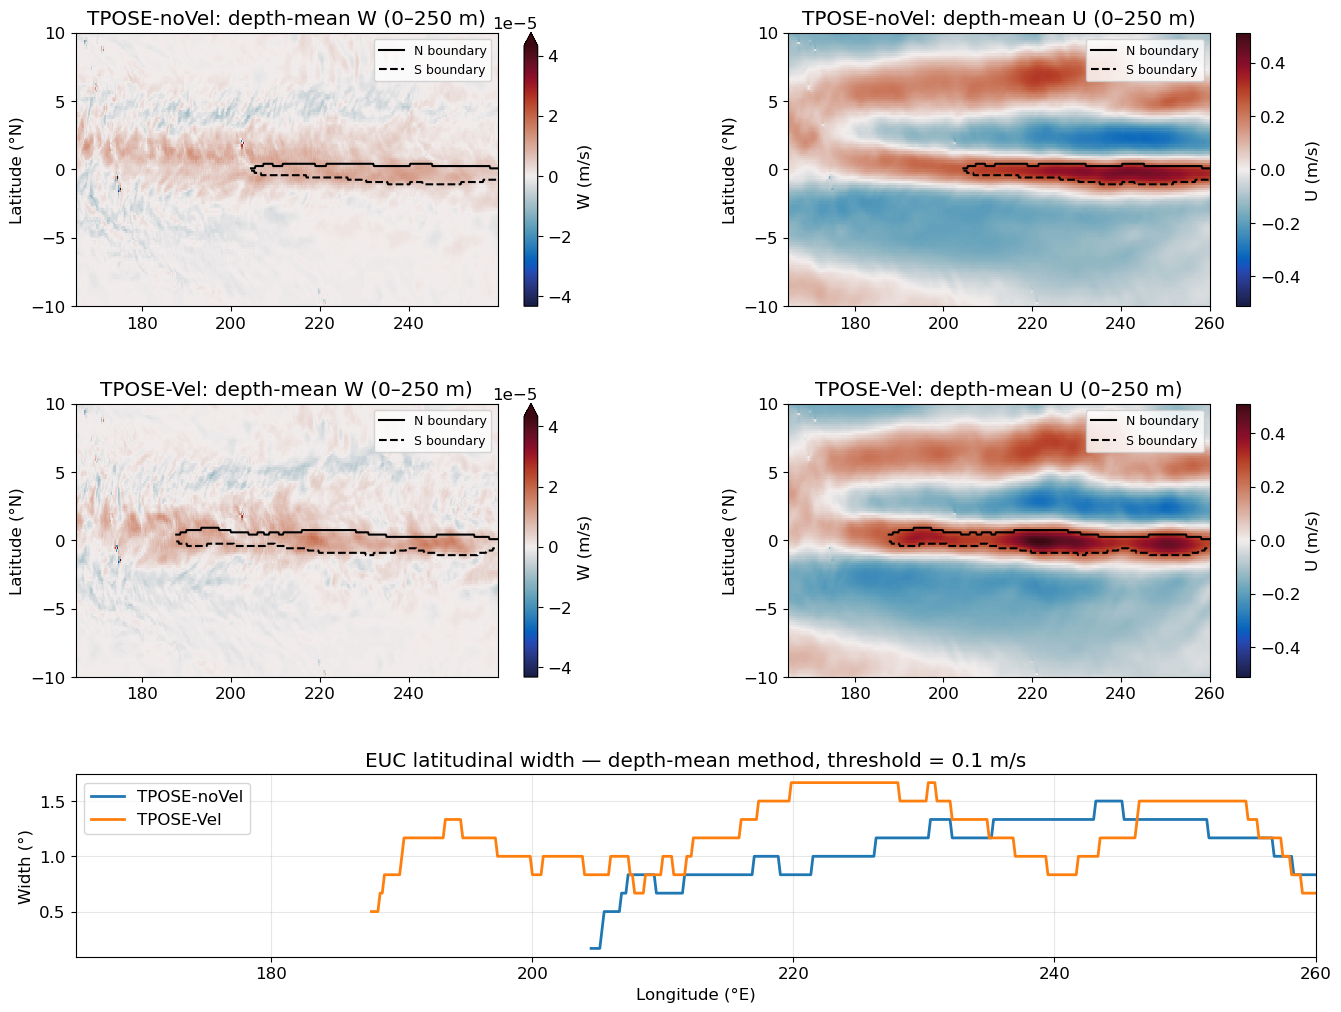

Saved EUC_width_depthmean.png


In [10]:
wlim2    = float(max(abs(wmean_novel).max(), abs(wmean_vel).max()))*0.75
ulim_abs = float(max(abs(umean_novel).max(), abs(umean_vel).max()))  # symmetric about 0

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[3, 3, 2], hspace=0.4, wspace=0.35)

# Row 1: noVel
ax00 = fig.add_subplot(gs[0, 0])
wmean_novel.plot(ax=ax00, vmin=-wlim2, vmax=wlim2, cmap=cmo.balance, cbar_kwargs={'label': 'W (m/s)'})
add_boundaries(ax00, n_mean_novel, s_mean_novel)
ax00.set_title('TPOSE-noVel: depth-mean W (0–250 m)')
ax00.set_xlabel('');  ax00.set_ylabel('Latitude (°N)')

ax01 = fig.add_subplot(gs[0, 1])
umean_novel.plot(ax=ax01, vmin=-ulim_abs, vmax=ulim_abs, cmap=cmo.balance, cbar_kwargs={'label': 'U (m/s)'})
add_boundaries(ax01, n_mean_novel, s_mean_novel)
ax01.set_title('TPOSE-noVel: depth-mean U (0–250 m)')
ax01.set_xlabel('');  ax01.set_ylabel('Latitude (°N)')

# Row 2: Vel
ax10 = fig.add_subplot(gs[1, 0])
wmean_vel.plot(ax=ax10, vmin=-wlim2, vmax=wlim2, cmap=cmo.balance, cbar_kwargs={'label': 'W (m/s)'})
add_boundaries(ax10, n_mean_vel, s_mean_vel)
ax10.set_title('TPOSE-Vel: depth-mean W (0–250 m)')
ax10.set_xlabel('');  ax10.set_ylabel('Latitude (°N)')

ax11 = fig.add_subplot(gs[1, 1])
umean_vel.plot(ax=ax11, vmin=-ulim_abs, vmax=ulim_abs, cmap=cmo.balance, cbar_kwargs={'label': 'U (m/s)'})
add_boundaries(ax11, n_mean_vel, s_mean_vel)
ax11.set_title('TPOSE-Vel: depth-mean U (0–250 m)')
ax11.set_xlabel('');  ax11.set_ylabel('Latitude (°N)')

# Row 3: width(lon)
ax2 = fig.add_subplot(gs[2, :])
ax2.plot(w_mean_novel.XG.values, w_mean_novel.values, color='C0', lw=2, label='TPOSE-noVel')
ax2.plot(w_mean_vel.XG.values,   w_mean_vel.values,   color='C1', lw=2, label='TPOSE-Vel')
ax2.set_xlabel('Longitude (°E)')
ax2.set_ylabel('Width (°)')
ax2.set_title('EUC latitudinal width — depth-mean method, threshold = 0.1 m/s')
ax2.legend()
ax2.set_xlim([165, 260])
ax2.grid(True, alpha=0.3)

fig.savefig(fig_dir + 'EUC_width_depthmean.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved EUC_width_depthmean.png')

## Method 3 — instantaneous core-following

At each time step:
1. Find the **2D maximum** of UVEL over the (Z, lat) plane within ±1° of the equator at each longitude → gives (z_core, lat_core)(lon, t) simultaneously.
2. Extract both UVEL(lat) and WVEL(lat, lon) at z_core depth and that time.
3. Walk N/S from lat_core in the UVEL profile until U < threshold → instantaneous EUC width.

Figure 3 shows the **time-mean of UVEL and WVEL at the instantaneous core depth**
with the **time-mean of the instantaneous EUC width** overlaid.

In [11]:
def calc_euc_width_instantaneous(uvel_4d, wvel_4d=None, threshold=0.3, lat_eq=(-1, 1)):
    """
    EUC width computed at each time step before time-averaging (Method 3).

    At each time step:
      1. Find the 2D maximum of UVEL over (Z, lat) within ±lat_eq band at each lon
         → gives (z_core, lat_core)(lon, t) simultaneously.
      2. Extract UVEL(lat) and (optionally) WVEL(lat, lon) at z_core depth and that time.
      3. Walk N/S from lat_core in the UVEL profile until U drops below threshold.

    Parameters
    ----------
    uvel_4d   : DataArray(time, Z, YC, XG) — full 4D UVEL, 0–250 m.
    wvel_4d   : DataArray(time, Z, YC, XG) — WVEL pre-interpolated to the UVEL grid (optional).
    threshold : float — EUC edge speed (m/s).
    lat_eq    : tuple — latitude band for locating the EUC core.

    Returns
    -------
    u_at_core_mean : DataArray(YC, XG) — time-mean U at the instantaneous core depth
    w_at_core_mean : DataArray(YC, XG) or None — time-mean W at the instantaneous core depth
    lat_north_da, lat_south_da, width_da, lat_core_da : DataArrays(XG) — time-mean boundaries and core lat
    """
    lats = uvel_4d.YC.values
    lons = uvel_4d.XG.values
    u3d  = uvel_4d.values           # (T, K, J, I)
    T, K, J, I = u3d.shape

    # Step 1: 2D argmax over (Z, lat_eq_band) at each (time, lon) → z_core and lat_core
    lat_eq_mask = (lats >= lat_eq[0]) & (lats <= lat_eq[1])
    eq_inds     = np.where(lat_eq_mask)[0]
    n_eq        = len(eq_inds)

    u_eq      = u3d[:, :, lat_eq_mask, :]    # (T, K, n_eq, I)
    u_eq_flat = u_eq.reshape(T, K * n_eq, I)
    flat_idx  = np.nanargmax(u_eq_flat, axis=1)  # (T, I)
    i_z_core      = flat_idx // n_eq              # (T, I)
    i_lat_core_eq = flat_idx % n_eq               # (T, I) local index in ±1° band

    # Step 2a: extract U(lat) at instantaneous core depth
    tt, ii    = np.meshgrid(np.arange(T), np.arange(I), indexing='ij')  # (T, I)
    u_at_core = u3d[
        tt[:, np.newaxis, :],
        i_z_core[:, np.newaxis, :],
        np.arange(J)[np.newaxis, :, np.newaxis],
        ii[:, np.newaxis, :]
    ]  # (T, J, I)

    # Step 2b: extract W(lat, lon) at core depth — wvel_4d must be on same (Z, YC, XG) grid
    w_at_core_mean = None
    if wvel_4d is not None:
        w3d = wvel_4d.values  # (T, K, J, I) — same shape as u3d
        w_at_core = w3d[
            tt[:, np.newaxis, :],
            i_z_core[:, np.newaxis, :],
            np.arange(J)[np.newaxis, :, np.newaxis],
            ii[:, np.newaxis, :]
        ]  # (T, J, I)
        w_at_core_mean = xr.DataArray(
            np.nanmean(w_at_core, axis=0),
            coords={'YC': lats, 'XG': lons}, dims=['YC', 'XG']
        )

    # Step 3: EUC width and core latitude at each time step
    lat_north = np.full((T, I), np.nan)
    lat_south = np.full((T, I), np.nan)
    lat_core  = np.full((T, I), np.nan)

    for t in range(T):
        if t % 50 == 0:
            print(f'  time step {t}/{T}')
        for j in range(I):
            u_prof = u_at_core[t, :, j]
            if np.nanmax(u_prof) < threshold:
                continue

            i_lat_core = eq_inds[i_lat_core_eq[t, j]]
            lat_core[t, j] = lats[i_lat_core]

            i_north = J - 1
            for i in range(i_lat_core + 1, J):
                if u_prof[i] < threshold:
                    i_north = i - 1
                    break

            i_south = 0
            for i in range(i_lat_core - 1, -1, -1):
                if u_prof[i] < threshold:
                    i_south = i + 1
                    break

            lat_north[t, j] = lats[i_north]
            lat_south[t, j] = lats[i_south]

    u_at_core_mean = xr.DataArray(
        np.nanmean(u_at_core, axis=0),
        coords={'YC': lats, 'XG': lons}, dims=['YC', 'XG']
    )
    lat_north_da = xr.DataArray(np.nanmean(lat_north, axis=0), coords={'XG': lons}, dims='XG')
    lat_south_da = xr.DataArray(np.nanmean(lat_south, axis=0), coords={'XG': lons}, dims='XG')
    lat_core_da  = xr.DataArray(np.nanmean(lat_core,  axis=0), coords={'XG': lons}, dims='XG')
    lat_core_std = xr.DataArray(np.nanstd(lat_core, axis=0), coords={'XG': lons}, dims='XG')
    width_da     = lat_north_da - lat_south_da
    return u_at_core_mean, w_at_core_mean, lat_north_da, lat_south_da, width_da, lat_core_da, lat_core_std

In [12]:
from xgcm import Grid as xgcm_Grid

def _interp_wvel_to_ugrid(ds, lat_map, lon_slice):
    """Interpolate WVEL from (Zl, YC, XC) to (Z, YC, XG) using xgcm."""
    grid = xgcm_Grid(ds, coords={
        'X': {'center': 'XC', 'left': 'XG'},
        'Y': {'center': 'YC', 'left': 'YG'},
        'Z': {'center': 'Z', 'outer': 'Zl'}
    }, periodic=['X', 'Y'], autoparse_metadata=False)
    wvel_on_u = grid.interp(grid.interp(ds.WVEL, 'Z', boundary='fill'), 'X')
    return wvel_on_u.sel(Z=slice(0, -250), YC=lat_map, XG=lon_slice)

print('Method 3: noVel...')
uvel_4d_novel = ds_novel.UVEL.sel(Z=slice(0, -250), YC=lat_map, XG=lon_slice)
wvel_4d_novel = _interp_wvel_to_ugrid(ds_novel, lat_map, lon_slice)
u_core_novel, w_core_novel, n_inst_novel, s_inst_novel, w_inst_novel, lat_core_novel, lat_core_std_novel = calc_euc_width_instantaneous(uvel_4d_novel, wvel_4d=wvel_4d_novel)

print('Method 3: Vel...')
uvel_4d_vel = ds_vel.UVEL.sel(Z=slice(0, -250), YC=lat_map, XG=lon_slice)
wvel_4d_vel = _interp_wvel_to_ugrid(ds_vel, lat_map, lon_slice)
u_core_vel, w_core_vel, n_inst_vel, s_inst_vel, w_inst_vel, lat_core_vel, lat_core_std_vel = calc_euc_width_instantaneous(uvel_4d_vel, wvel_4d=wvel_4d_vel)

print(f'\nMethod 3: mean width noVel = {float(w_inst_novel.mean()):.2f}°, Vel = {float(w_inst_vel.mean()):.2f}°')
print(f'Method 3: mean core lat noVel = {float(lat_core_novel.mean()):.2f}°N, Vel = {float(lat_core_vel.mean()):.2f}°N')

Method 3: noVel...
  time step 0/303
  time step 50/303
  time step 100/303
  time step 150/303
  time step 200/303
  time step 250/303
  time step 300/303
Method 3: Vel...
  time step 0/303
  time step 50/303
  time step 100/303
  time step 150/303
  time step 200/303
  time step 250/303
  time step 300/303

Method 3: mean width noVel = 2.56°, Vel = 2.53°
Method 3: mean core lat noVel = -0.01°N, Vel = 0.01°N


## Figure 3: time-mean U at instantaneous core depth, Method 3 boundaries

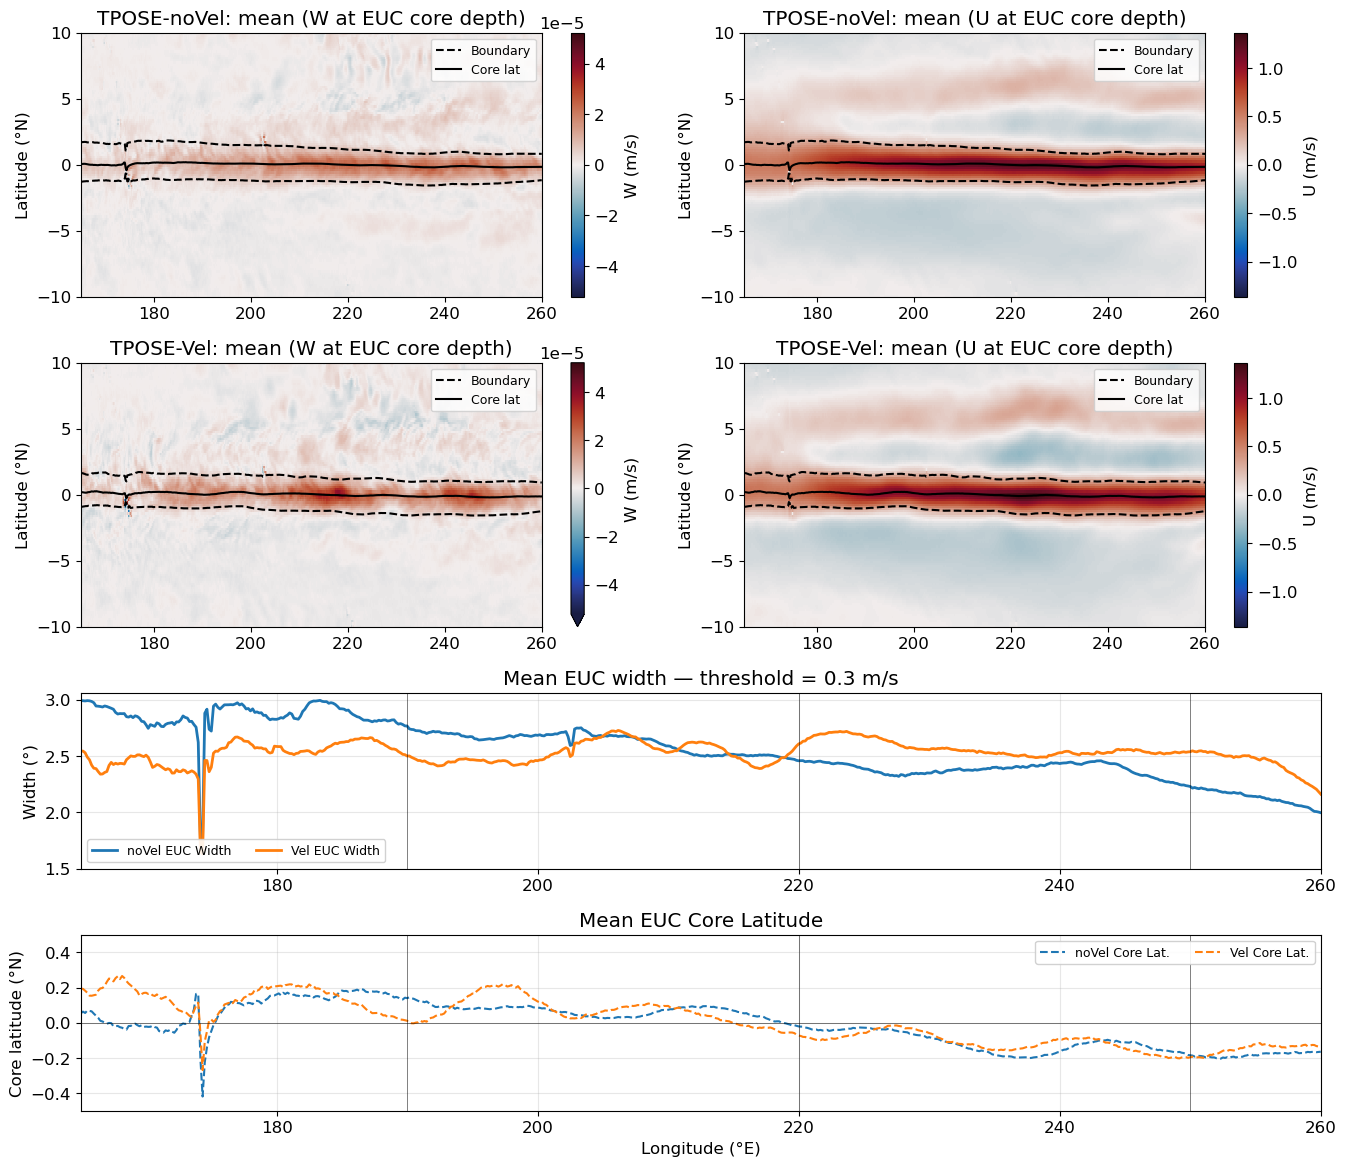

Saved EUC_width_instantaneous.png


In [13]:
def _add_inst_lines(ax, n, s, core):
    """Figure 3 map overlay: dashed N/S boundaries + solid core latitude, all black."""
    ax.plot(n.XG.values,    n.values,    '--', lw=1.5, color='k', label='Boundary')
    ax.plot(s.XG.values,    s.values,    '--', lw=1.5, color='k', label='_nolegend_')
    ax.plot(core.XG.values, core.values, '-',  lw=1.5, color='k', label='Core lat')
    ax.legend(fontsize=9, loc='upper right')

ulim3 = float(max(abs(u_core_novel).max(), abs(u_core_vel).max()))
wlim3 = float(max(abs(w_core_novel).max(), abs(w_core_vel).max()))*0.75

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[3, 3, 2, 2], hspace=0.3, wspace=0.15)

# Row 1: noVel
ax00 = fig.add_subplot(gs[0, 0])
w_core_novel.plot(ax=ax00, vmin=-wlim3, vmax=wlim3, cmap=cmo.balance, cbar_kwargs={'label': 'W (m/s)'})
_add_inst_lines(ax00, n_inst_novel, s_inst_novel, lat_core_novel)
ax00.set_title('TPOSE-noVel: mean (W at EUC core depth)')
ax00.set_xlabel('');  ax00.set_ylabel('Latitude (°N)')

ax01 = fig.add_subplot(gs[0, 1])
u_core_novel.plot(ax=ax01, vmin=-ulim3, vmax=ulim3, cmap=cmo.balance, cbar_kwargs={'label': 'U (m/s)'})
_add_inst_lines(ax01, n_inst_novel, s_inst_novel, lat_core_novel)
ax01.set_title('TPOSE-noVel: mean (U at EUC core depth)')
ax01.set_xlabel('');  ax01.set_ylabel('Latitude (°N)')

# Row 2: Vel
ax10 = fig.add_subplot(gs[1, 0])
w_core_vel.plot(ax=ax10, vmin=-wlim3, vmax=wlim3, cmap=cmo.balance, cbar_kwargs={'label': 'W (m/s)'})
_add_inst_lines(ax10, n_inst_vel, s_inst_vel, lat_core_vel)
ax10.set_title('TPOSE-Vel: mean (W at EUC core depth)')
ax10.set_xlabel('');  ax10.set_ylabel('Latitude (°N)')

ax11 = fig.add_subplot(gs[1, 1])
u_core_vel.plot(ax=ax11, vmin=-ulim3, vmax=ulim3, cmap=cmo.balance, cbar_kwargs={'label': 'U (m/s)'})
_add_inst_lines(ax11, n_inst_vel, s_inst_vel, lat_core_vel)
ax11.set_title('TPOSE-Vel: mean (U at EUC core depth)')
ax11.set_xlabel('');  ax11.set_ylabel('Latitude (°N)')

# mooring locations
mooring_lons = [190, 220, 250]

# Row 3: width(lon) primary y-axis + core latitude secondary y-axis
ax2 = fig.add_subplot(gs[2, :])
ax2.plot(w_inst_novel.XG.values, w_inst_novel.values, color='C0', lw=2, label='noVel EUC Width')
ax2.plot(w_inst_vel.XG.values,   w_inst_vel.values,   color='C1', lw=2, label='Vel EUC Width')
ax2.set_ylabel('Width (°)')
ax2.set_xlabel('')
ax2.set_title('Mean EUC width — threshold = 0.3 m/s')
ax2.set_xlim([165, 260])
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=1.5)
ax2.axvline(mooring_lons[0], color='k', lw=0.5, alpha=0.7)
ax2.axvline(mooring_lons[1], color='k', lw=0.5, alpha=0.7)
ax2.axvline(mooring_lons[2], color='k', lw=0.5, alpha=0.7)
ax2.legend(loc='lower left', fontsize=9, ncol=2, framealpha=0.9)

ax3 = fig.add_subplot(gs[3, :])
ax3.plot(lat_core_novel.XG.values, lat_core_novel.values, '--', color='C0', lw=1.5, label='noVel Core Lat.')
ax3.plot(lat_core_vel.XG.values,   lat_core_vel.values,   '--', color='C1', lw=1.5, label='Vel Core Lat.')
# ax3.plot(lat_core_std_novel.XG.values, lat_core_std_novel.values, ':', color='C0', lw=1.5, label='noVel Core Lat. Std.')
# ax3.plot(lat_core_std_vel.XG.values,   lat_core_std_vel.values,   ':', color='C1', lw=1.5, label='Vel Core Lat. Std.')
ax3.axhline(0, color='k', lw=0.5, alpha=0.7)
ax3.axvline(mooring_lons[0], color='k', lw=0.5, alpha=0.7)
ax3.axvline(mooring_lons[1], color='k', lw=0.5, alpha=0.7)
ax3.axvline(mooring_lons[2], color='k', lw=0.5, alpha=0.7)
ax3.set_ylabel('Core latitude (°N)')
ax3.set_ylim([-0.5, 0.5])
ax3.grid(True, alpha=0.3)
ax3.set_xlim([165, 260])
ax3.set_title('Mean EUC Core Latitude')
ax3.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.9)
ax3.set_xlabel('Longitude (°E)')

fig.savefig(fig_dir + 'EUC_width_instantaneous.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved EUC_width_instantaneous.png')